In [1]:
import numpy as np
import torch
import torch.nn as nn

from heston.pinn.heston_pinn_nd import HestonMultiAssetPINN
from utility.model import EarlyStopping
from config.heston_nd import *

In [2]:
seeds = [42]
for seed in seeds:
    print(f'Training model with seed {seed}...')
    pinn = HestonMultiAssetPINN(model_config, seed)
    pinn.set_params(K, r, T, kappa, theta, sigma_bar, sigmas, corr, rho_cross, S_min, S_max, V_min, V_max)
    pinn.set_loss_weights(loss_weights)
    early_stopping = EarlyStopping(patience=1500, min_delta=1e-7)
    pinn.train(batch_size=4096, epochs=40000, early_stopping=early_stopping)
    pinn.save(f'../../models/heston_pinn_nd/{seed}.pth')


Training model with seed 42...
Iteration 0 | Training Loss: 1.307e-01 | Validation Loss: 1.252e-01 | Max interior sq-residual: 1.122e-01
Iteration 500 | Training Loss: 1.630e-03 | Validation Loss: 1.526e-03 | Max interior sq-residual: 1.381e-02
Iteration 1000 | Training Loss: 7.777e-04 | Validation Loss: 7.743e-04 | Max interior sq-residual: 9.154e-03
Iteration 1500 | Training Loss: 4.737e-04 | Validation Loss: 4.555e-04 | Max interior sq-residual: 9.615e-03
Iteration 2000 | Training Loss: 3.063e-04 | Validation Loss: 3.089e-04 | Max interior sq-residual: 4.220e-03
Iteration 2500 | Training Loss: 2.102e-04 | Validation Loss: 2.092e-04 | Max interior sq-residual: 4.582e-03
Iteration 3000 | Training Loss: 1.777e-04 | Validation Loss: 1.674e-04 | Max interior sq-residual: 4.532e-03
Iteration 3500 | Training Loss: 1.310e-04 | Validation Loss: 1.322e-04 | Max interior sq-residual: 3.099e-03
Iteration 4000 | Training Loss: 1.301e-04 | Validation Loss: 1.275e-04 | Max interior sq-residual: 3.

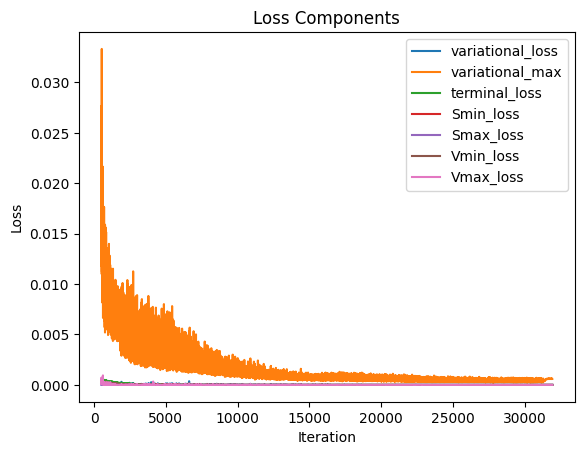

In [3]:
pinn.plot_losses(start_epoch=500, detailed=True)